# Notebook 05 — Risk Assessment

## Motivation

Notebook 04 answered: *how likely is a crash?*  
Notebook 05 answers: *if a crash happens, how bad could it be?*

Knowing only the crash probability is not enough for a portfolio manager. 
A 30% crash probability means very different things depending on whether 
the expected loss is 5% or 50%. This notebook quantifies the downside 
severity using two standard risk measures: Value at Risk (VaR) and 
Expected Shortfall (ES).

---

## What VaR and ES mean

**Value at Risk (VaR) at 95%**  
The minimum loss in the worst 5% of scenarios over the next month.  
Example: VaR 95% = -11,808 USD/MT means there is a 5% chance that 
the price drops by more than 11,808 USD/MT next month.

**Expected Shortfall (ES) at 95%**  
The average loss given that you are already in that worst 5%.  
Example: ES 95% = -13,160 USD/MT means that conditional on being 
in the worst 5% of scenarios, the average loss is 13,160 USD/MT.

ES is more informative than VaR because VaR only tells you the 
threshold, while ES tells you how severe the losses are beyond it. 
For this reason, ES has become the preferred risk measure under 
the Basel III regulatory framework for banks.

Both measures are reported at 95% and 99% confidence levels, 
and computed for both the simulation-based and sample-based 
forecasting methods.

---

## What exactly we computed

The MAR(1,1) predictive density gives the full distribution of 
next month's noncausal component u*_{T+1}. We convert this into 
a distribution of one-month changes:

    change = u*_{T+1} - u_T

VaR is the 5th percentile of that change distribution.  
ES is the average of all changes below that 5th percentile.

These are computed on the forward-looking bubble component of 
the nickel price — the part of the price driven by future 
expectations rather than past dynamics. This means our VaR and 
ES specifically measure bubble-specific downside risk: how much 
of the speculative price excess above fundamental value could be 
lost next month.

---

## Concrete example: Point 5 (May 2007, peak of bubble)

At the peak of the 2007 nickel bubble:
- Raw nickel price: 52,179 USD/MT
- Fundamental trend (HP filter): 23,594 USD/MT
- Bubble component (cycle): 28,585 USD/MT
- Forward-looking bubble component (u_T): 10,946 USD/MT

| Measure | Simulation-based | Sample-based |
|---------|-----------------|--------------|
| VaR 95% | -11,808 USD/MT  | -12,098 USD/MT |
| ES 95%  | -13,160 USD/MT  | -13,073 USD/MT |
| VaR 99% | -13,692 USD/MT  | -13,257 USD/MT |
| ES 99%  | -15,739 USD/MT  | -14,799 USD/MT |

At the peak, VaR 95% of -11,808 USD/MT exceeds the current 
forward-looking component of 10,946 USD/MT — meaning the worst 
5% of scenarios imply a complete collapse of the speculative 
bubble component back to or below zero. ES 95% of -13,160 
confirms this: conditional on a crash scenario, the average 
landing point is around -2,214 USD/MT, consistent with the 
crash mode in the predictive density sitting below zero.

---

## Results across all forecast points

| Point | Date    | VaR 95% (sim)  | ES 95% (sim)   |
|-------|---------|----------------|----------------|
| 1     | 2006-05 | -942 USD/MT    | -1,535 USD/MT  |
| 2     | 2006-09 | -3,260 USD/MT  | -4,192 USD/MT  |
| 3     | 2007-02 | -7,462 USD/MT  | -8,636 USD/MT  |
| 4     | 2007-03 | -9,490 USD/MT  | -10,739 USD/MT |
| 5     | 2007-05 | -11,808 USD/MT | -13,160 USD/MT |
| 6     | 2011-02 | -3,260 USD/MT  | -4,193 USD/MT  |

Both VaR and ES grow steadily from Point 1 to Point 5, 
reflecting the increasing severity of a potential crash as the 
bubble builds. At Point 1 (normal period, Q=0.48) the risk 
measures are modest. By Point 5 (peak, Q=0.998) they have grown 
by more than tenfold. Point 6, occurring after the crash when 
the price has returned to a similar quantile as Point 2, shows 
risk measures comparable to Point 2 — confirming that the model 
correctly recognizes the reduced bubble risk post-crash.

---

## Two methods, two perspectives

The **simulation-based method** gives purely model-implied risk 
— what the estimated MAR parameters say the downside risk should 
be, independent of history.

The **sample-based method** gives historically-learned risk — 
adjusted by what actually happened in the past. If the series 
has previously reached similar levels and continued rising, the 
sample-based method assigns less crash risk. If the current 
level is unprecedented, it assigns more.

The shaded area in the plot below represents the **learning 
component** — the gap between the two methods. A wider shaded 
area means historical experience is significantly adjusting the 
model-implied risk estimate. During the 2007 nickel bubble, 
the two methods remain relatively close, suggesting that 
nickel's long price history (1980-2019) provides reasonable 
historical context even at bubble levels.

---

## Portfolio relevance

These risk measures have direct practical implications for 
portfolio management. VaR and ES derived from MAR predictive 
densities offer two key advantages over conventional risk 
measures such as historical VaR or GARCH-based VaR:

**1. They capture bimodality**  
Standard risk models assume approximately normal return 
distributions. During bubble episodes the MAR predictive 
density is explicitly bimodal — there is a crash mode and a 
continuation mode. Conventional VaR misses the crash mode 
entirely, systematically underestimating tail risk during 
bubble episodes.

**2. They are forward-looking**  
The noncausal component of the MAR model aggregates future 
shocks, making the risk measures anticipative. They signal 
increasing downside risk before the crash occurs, not after. 
This gives a portfolio manager an early warning system that 
conventional backward-looking risk models cannot provide.

In practice, a portfolio manager holding nickel exposure could 
use the MAR-based VaR as a dynamic position-sizing signal — 
reducing exposure as VaR deteriorates along the bubble 
trajectory, and re-entering after the crash when VaR normalizes.

## Comparison to conventional bank risk models

Most large financial institutions compute VaR and ES using 
historical simulation (sorting past returns), parametric methods 
(assuming normal distributions), or Monte Carlo simulation. 
Under Basel III, banks are required to report ES at 97.5% 
confidence for market risk capital — but the underlying models 
remain largely the same. We can argue that bank risk models systematically underestimate tail risk during bubble episodes.

**The key limitation**

All conventional approaches assume approximately normal, 
unimodal return distributions. During a speculative bubble the 
true distribution is bimodal — crash mode and continuation mode. 
Conventional models miss the crash mode entirely, 
systematically underestimating tail risk precisely when it 
matters most.

**What MAR-based risk measures add**

The MAR predictive density explicitly captures bimodality, 
producing VaR and ES estimates that are forward-looking (driven 
by the noncausal component), bimodal-aware, and dynamic — 
increasing as the bubble builds and normalizing after the crash. 
This makes MAR-based risk measures a natural complement to 
conventional bank models during periods of suspected speculative 
activity.

In [7]:
# ── Imports and load data ──────────────────────────────────────
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.preprocessing import load_data

# Load model parameters and series
params, series = load_data()

# Load forecast points (same as notebook 04)
forecast_points = pd.DataFrame({
    'Date': pd.to_datetime([
        '2006-05-01',
        '2006-09-01',
        '2007-02-01',
        '2007-03-01',
        '2007-05-01',
        '2011-02-01',
    ]),
    'Label': ['Point 1', 'Point 2', 'Point 3', 'Point 4', 'Point 5', 'Point 6']
})

forecast_points['cycle'] = [
    float(series.loc[date, 'cycle']) for date in forecast_points['Date']
]
forecast_points['u_t'] = [
    float(series.loc[date, 'u_t']) for date in forecast_points['Date']
]
forecast_points['Quantile'] = [
    (series['cycle'] < row['cycle']).mean()
    for _, row in forecast_points.iterrows()
]

# Load the saved CDFs
cdfs = {}
for i in range(1, 7):
    cdfs[i] = pd.read_csv(f'../outputs/tables/risk/point_{i}.csv')

print("Loaded 6 forecast points and CDFs")
print(forecast_points[['Label', 'Date', 'Quantile']].to_string(index=False))

Parameters : MAR(1,1) | φ=0.617062379728722, ψ=0.777070127450962, df=1.4947, σ=402.94
Series     : 475 obs [1980-02 → 2019-08]
Loaded 6 forecast points and CDFs
  Label       Date  Quantile
Point 1 2006-05-01  0.480000
Point 2 2006-09-01  0.964211
Point 3 2007-02-01  0.989474
Point 4 2007-03-01  0.993684
Point 5 2007-05-01  0.997895
Point 6 2011-02-01  0.966316


In [8]:
# ── Compute VaR and ES at each forecast point ──────────────────

def compute_var_es(grid, cdf, u_T, confidence=0.95):
    """
    VaR and ES on one-period change: change = u*_{T+1} - u_T
    Shifts grid so we work with changes from current level.
    """
    threshold = 1 - confidence  # 0.05 for 95%, 0.01 for 99%
    
    # Shift grid to changes
    changes = grid - u_T
    
    # VaR: change at threshold percentile (negative = loss)
    idx_var = np.searchsorted(cdf, threshold)
    idx_var = min(idx_var, len(changes) - 1)
    var = changes[idx_var]
    
    # ES: average change in worst scenarios below VaR
    mask = cdf <= threshold
    if mask.sum() == 0:
        es = var
    else:
        weights = np.diff(cdf[mask], prepend=0)
        weights = np.abs(weights)
        if weights.sum() == 0:
            es = changes[mask].mean()
        else:
            es = np.average(changes[mask], weights=weights)
    
    return var, es


results = []

for i, (idx, point) in enumerate(forecast_points.iterrows()):
    df = cdfs[i + 1]
    grid = df['grid'].values
    cdf_sim = df['cdf_sim'].values
    density_sample = df['density_sample'].values
    u_T = point['u_t']
    
    # Method 2: build CDF from density
    grid_step = grid[1] - grid[0]
    cdf_sample = np.cumsum(density_sample) * grid_step
    cdf_sample = cdf_sample / cdf_sample[-1]
    
    # Compute VaR and ES at 95% and 99%
    var95_sim,  es95_sim  = compute_var_es(grid, cdf_sim,    u_T, confidence=0.95)
    var99_sim,  es99_sim  = compute_var_es(grid, cdf_sim,    u_T, confidence=0.99)
    var95_samp, es95_samp = compute_var_es(grid, cdf_sample, u_T, confidence=0.95)
    var99_samp, es99_samp = compute_var_es(grid, cdf_sample, u_T, confidence=0.99)
    
    results.append({
        'Point':      point['Label'],
        'Date':       point['Date'].strftime('%Y-%m'),
        'Quantile':   round(point['Quantile'], 3),
        'VaR95_sim':  round(var95_sim,  1),
        'VaR95_samp': round(var95_samp, 1),
        'VaR95_diff': round(var95_samp - var95_sim, 1),
        'VaR99_sim':  round(var99_sim,  1),
        'VaR99_samp': round(var99_samp, 1),
        'VaR99_diff': round(var99_samp - var99_sim, 1),
        'ES95_sim':   round(es95_sim,   1),
        'ES95_samp':  round(es95_samp,  1),
        'ES95_diff':  round(es95_samp - es95_sim, 1),
        'ES99_sim':   round(es99_sim,   1),
        'ES99_samp':  round(es99_samp,  1),
        'ES99_diff':  round(es99_samp - es99_sim, 1),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

  Point    Date  Quantile  VaR95_sim  VaR95_samp  VaR95_diff  VaR99_sim  VaR99_samp  VaR99_diff  ES95_sim  ES95_samp  ES95_diff  ES99_sim  ES99_samp  ES99_diff
Point 1 2006-05     0.480     -941.8      -796.9       144.9    -1666.2     -1376.4       289.8   -1546.8    -1227.4      319.4   -2426.2    -1921.9      504.3
Point 2 2006-09     0.964    -3260.0     -3694.6      -434.7    -4564.0     -4564.0         0.0   -4179.2    -4334.3     -155.1   -5697.5    -5421.5      276.0
Point 3 2007-02     0.989    -7606.6     -7896.4      -289.8    -9200.4     -8910.6       289.8   -8782.7    -8743.1       39.6  -10858.0   -10142.9      715.1
Point 4 2007-03     0.994    -9635.0     -9924.8      -289.8   -11373.7    -11083.9       289.8  -10911.9   -10856.1       55.9  -13219.4   -12545.3      674.0
Point 5 2007-05     0.998   -11953.2    -12098.1      -144.9   -13691.9    -13257.2       434.7  -13346.0   -13073.3      272.8  -15771.9   -14799.2      972.7
Point 6 2011-02     0.966    -3260.0    

In [9]:
# Get exact numbers at Point 5
date = pd.Timestamp('2007-05-01')

# Load raw data
raw = pd.read_csv('../data/raw/nickel_prices_1980_2019.csv')
raw['Date'] = pd.to_datetime(raw['Date'].str.replace('M', '-'), format='%Y-%m')
raw = raw.set_index('Date')

cycle = float(series.loc[date, 'cycle'])
raw_price = float(raw.loc[date].iloc[0])
trend = raw_price - cycle

print(f"Raw price : {raw_price:.0f} USD/MT")
print(f"Trend     : {trend:.0f} USD/MT")
print(f"Cycle     : {cycle:.0f} USD/MT")
print(f"u_T       : {float(series.loc[date, 'u_t']):.0f} USD/MT")

Raw price : 52179 USD/MT
Trend     : 23594 USD/MT
Cycle     : 28585 USD/MT
u_T       : 10946 USD/MT


In [10]:
# ── Load all bubble period CDFs and compute VaR/ES ──────────────
import os

date_range = pd.date_range(start='2006-01-01', end='2012-01-01', freq='MS')

all_results = []

for date in date_range:
    filename = f'../outputs/tables/risk_all/{date.strftime("%Y-%m")}.csv'
    if not os.path.exists(filename):
        print(f"Skipping {date.strftime('%Y-%m')} — file not found")
        continue
    
    df = pd.read_csv(filename)
    grid = df['grid'].values
    cdf_sim = df['cdf_sim'].values
    density_sample = df['density_sample'].values
    u_T = float(series.loc[date, 'u_t'])
    
    # Build sample CDF from density
    grid_step = grid[1] - grid[0]
    cdf_sample = np.cumsum(density_sample) * grid_step
    cdf_sample = cdf_sample / cdf_sample[-1]
    
    var95_sim,  es95_sim  = compute_var_es(grid, cdf_sim,    u_T, confidence=0.95)
    var95_samp, es95_samp = compute_var_es(grid, cdf_sample, u_T, confidence=0.95)
    
    all_results.append({
        'Date':        date,
        'u_T':         u_T,
        'VaR95_sim':   round(var95_sim,  1),
        'VaR95_samp':  round(var95_samp, 1),
        'ES95_sim':    round(es95_sim,   1),
        'ES95_samp':   round(es95_samp,  1),
    })

all_df = pd.DataFrame(all_results).set_index('Date')
print(f"Loaded {len(all_df)} monthly points")
print(all_df.head(10).to_string())

Loaded 73 monthly points
                    u_T  VaR95_sim  VaR95_samp  ES95_sim  ES95_samp
Date                                                               
2006-01-01 -2256.335601    -1231.5     -1086.7   -1887.2    -1672.7
2006-02-01 -2199.798609    -1231.5      -941.8   -1892.9    -1489.0
2006-03-01 -2334.024897    -1231.5     -1086.7   -1911.6    -1671.5
2006-04-01 -1268.231465     -941.8      -796.9   -1536.8    -1255.9
2006-05-01  -164.724074     -941.8      -796.9   -1540.8    -1227.4
2006-06-01  -381.674735     -941.8      -796.9   -1534.1    -1242.0
2006-07-01  1761.964025    -1956.0     -2390.6   -2758.0    -2954.5
2006-08-01  3268.732408    -3549.7     -4129.3   -4491.0    -4806.5
2006-09-01  2953.322382    -3260.0     -3694.6   -4180.8    -4334.3
2006-10-01  3862.512389    -4274.2     -4708.8   -5280.4    -5406.8


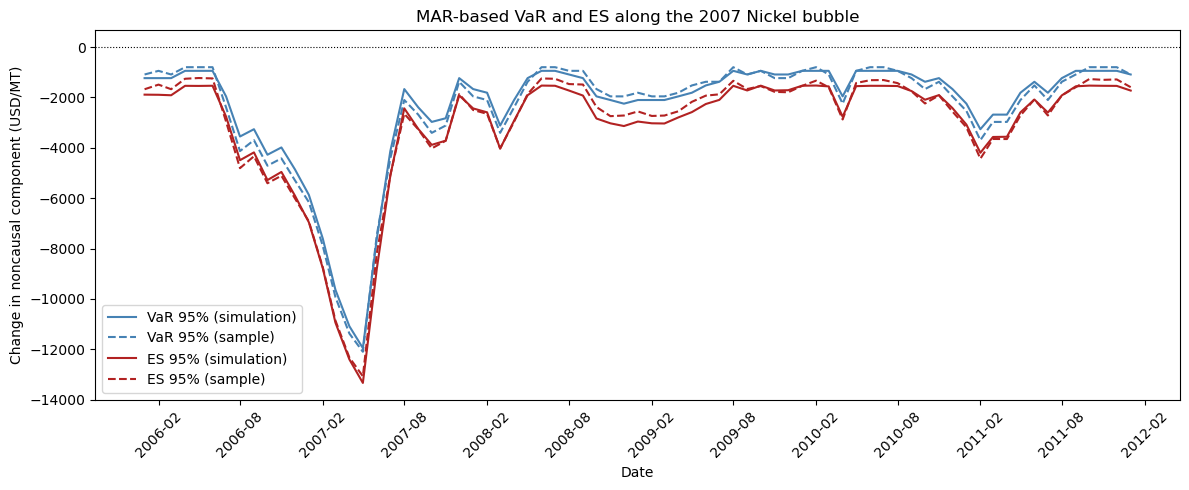

In [11]:
# ── Combined plot: VaR and ES evolution ────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(all_df.index, all_df['VaR95_sim'],  label='VaR 95% (simulation)',  color='steelblue',  linewidth=1.5)
ax.plot(all_df.index, all_df['VaR95_samp'], label='VaR 95% (sample)',      color='steelblue',  linewidth=1.5, linestyle='--')
ax.plot(all_df.index, all_df['ES95_sim'],   label='ES 95% (simulation)',   color='firebrick',  linewidth=1.5)
ax.plot(all_df.index, all_df['ES95_samp'],  label='ES 95% (sample)',       color='firebrick',  linewidth=1.5, linestyle='--')

ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

ax.set_xlabel('Date')
ax.set_ylabel('Change in noncausal component (USD/MT)')
ax.set_title('MAR-based VaR and ES along the 2007 Nickel bubble')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/11_var_es_evolution.png', dpi=150)
plt.show()

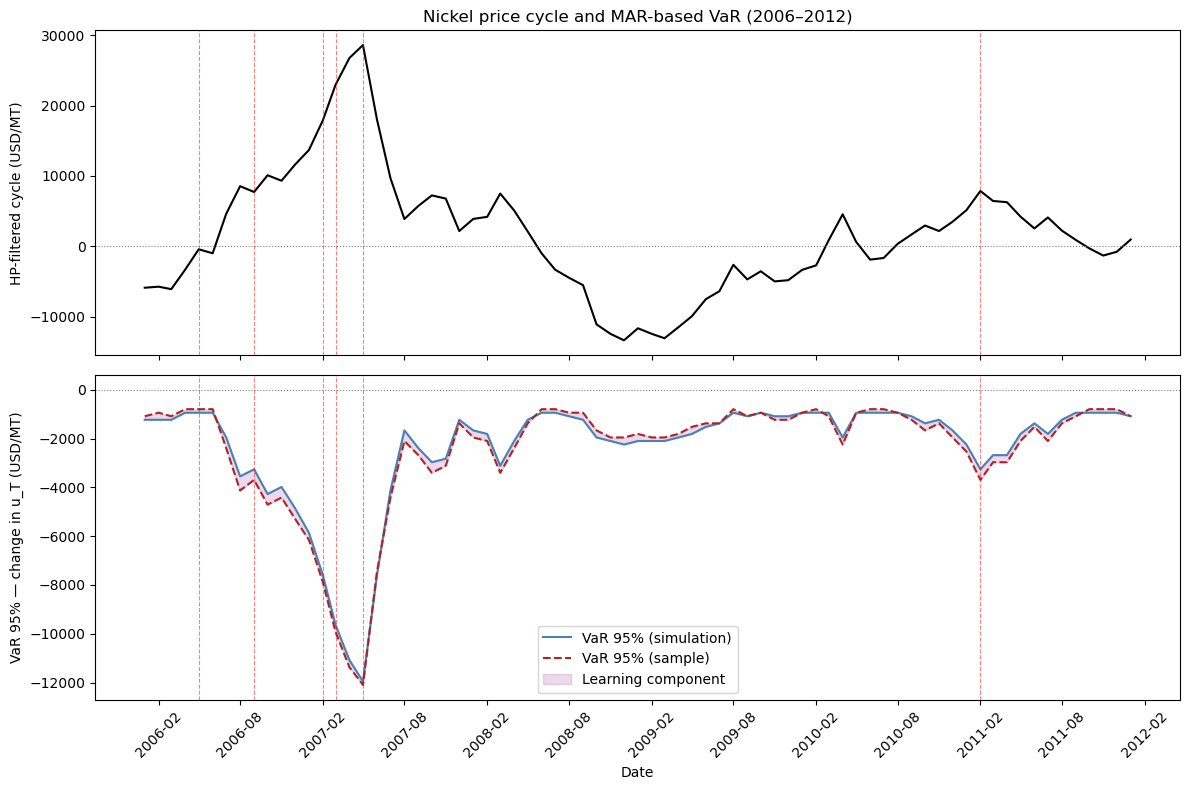

In [12]:
# ── Two-panel plot: Nickel cycle + VaR evolution ────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# ── Top panel: HP-filtered cycle ────────────────────────────────
cycle_plot = series.loc['2006-01':'2012-01', 'cycle']
ax1.plot(cycle_plot.index, cycle_plot.values, color='black', linewidth=1.5)
ax1.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax1.set_ylabel('HP-filtered cycle (USD/MT)')
ax1.set_title('Nickel price cycle and MAR-based VaR (2006–2012)')

# Mark the 6 forecast points
for _, point in forecast_points.iterrows():
    if pd.Timestamp('2006-01-01') <= point['Date'] <= pd.Timestamp('2012-01-01'):
        ax1.axvline(point['Date'], color='red', linewidth=0.8, linestyle='--', alpha=0.5)

# ── Bottom panel: VaR 95% both methods ──────────────────────────
ax2.plot(all_df.index, all_df['VaR95_sim'],  
         label='VaR 95% (simulation)', color='steelblue', linewidth=1.5)
ax2.plot(all_df.index, all_df['VaR95_samp'], 
         label='VaR 95% (sample)',     color='firebrick',  linewidth=1.5, linestyle='--')
ax2.fill_between(all_df.index, all_df['VaR95_sim'], all_df['VaR95_samp'], 
                 alpha=0.15, color='purple', label='Learning component')
ax2.axhline(0, color='grey', linewidth=0.8, linestyle=':')

# Mark the 6 forecast points
for _, point in forecast_points.iterrows():
    if pd.Timestamp('2006-01-01') <= point['Date'] <= pd.Timestamp('2012-01-01'):
        ax2.axvline(point['Date'], color='red', linewidth=0.8, linestyle='--', alpha=0.5)

ax2.set_ylabel('VaR 95% — change in u_T (USD/MT)')
ax2.set_xlabel('Date')
ax2.legend()

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('../outputs/figures/11_var_es_evolution.png', dpi=150)
plt.show()